# Parte 5 — Bonus: LoRA sobre BERTweet
### Workshop: Clasificación de Emociones en Twitter

BERTweet tiene ~110M parámetros — el doble que DistilBERT. LoRA permite adaptarlo con una fracción mínima de los parámetros.

BERTweet usa la arquitectura de BERT, cuyas proyecciones de atención tienen nombres distintos a DistilBERT:

| Modelo | Proyecciones |
|---|---|
| DistilBERT | `q_lin`, `k_lin`, `v_lin`, `out_lin` |
| BERTweet / BERT | `query`, `key`, `value`, `dense` |

**Prerequisito:** haber ejecutado `part-1-data.ipynb` y `part-2-pipeline.ipynb`

In [1]:
!pip install peft -q
%run tweeteval-part-2-pipeline.ipynb

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 374
    })
})
compute_metrics OK
make_tokenized_dataset OK
full_evaluation OK
plot_training_curves OK
make_trainer OK

Pipeline lista. Puedes continuar con part-3-distilbert.ipynb


In [2]:
from peft import LoraConfig, get_peft_model, TaskType

MODEL_CHECKPOINT = "vinai/bertweet-base"
HF_REPO          = "oscarv1114/tweeteval-emotion-bertweet-lora"  # <-- cambia esto
LR_LORA          = 2e-4   # más alto que full FT — pocos parámetros entrenables

## Dataset tokenizado

Reutilizamos el tokenizador de BERTweet del experimento anterior.

In [3]:
from transformers import AutoTokenizer

tok_bertweet = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, normalization=True)
ds_bertweet  = make_tokenized_dataset(tok_bertweet)
print(ds_bertweet)

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 374
    })
})


## Inspección de módulos

Antes de aplicar LoRA, inspeccionamos los nombres de las capas lineales de BERTweet.

In [4]:
from transformers import AutoModelForSequenceClassification

base_bt = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT, num_labels=NUM_LABELS,
    id2label=ID2LABEL, label2id=LABEL2ID)

print("Módulos lineales de BERTweet:")
for name, module in base_bt.named_modules():
    if isinstance(module, torch.nn.Linear):
        print(f"  {name}  [{module.in_features} → {module.out_features}]")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Módulos lineales de BERTweet:
  roberta.encoder.layer.0.attention.self.query  [768 → 768]
  roberta.encoder.layer.0.attention.self.key  [768 → 768]
  roberta.encoder.layer.0.attention.self.value  [768 → 768]
  roberta.encoder.layer.0.attention.output.dense  [768 → 768]
  roberta.encoder.layer.0.intermediate.dense  [768 → 3072]
  roberta.encoder.layer.0.output.dense  [3072 → 768]
  roberta.encoder.layer.1.attention.self.query  [768 → 768]
  roberta.encoder.layer.1.attention.self.key  [768 → 768]
  roberta.encoder.layer.1.attention.self.value  [768 → 768]
  roberta.encoder.layer.1.attention.output.dense  [768 → 768]
  roberta.encoder.layer.1.intermediate.dense  [768 → 3072]
  roberta.encoder.layer.1.output.dense  [3072 → 768]
  roberta.encoder.layer.2.attention.self.query  [768 → 768]
  roberta.encoder.layer.2.attention.self.key  [768 → 768]
  roberta.encoder.layer.2.attention.self.value  [768 → 768]
  roberta.encoder.layer.2.attention.output.dense  [768 → 768]
  roberta.encoder.layer.2.

### 📝 TODO 5.1 — Configurar y aplicar LoRA a BERTweet

In [7]:
# TODO 5.1 ── LoRA sobre BERTweet
# ─────────────────────────────────────────────────────────────────────────────

# 1. Definimos la configuración estricta siguiendo las instrucciones del enunciado
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"],    # Solo query y value como lo pide el texto
    modules_to_save=["classifier"]        # Forzamos el entrenamiento de la cabeza clasificadora
)

# 2. Aplicamos LoRA sobre el modelo base real 'base_bt'
model_bertweet_lora = get_peft_model(base_bt, lora_config)

# 3. Imprimimos el reporte de parámetros eficientes
model_bertweet_lora.print_trainable_parameters()

trainable params: 888,580 || all params: 135,791,624 || trainable%: 0.6544


### 📝 TODO 5.2 — Entrenar BERTweet-LoRA

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Iniciando el entrenamiento optimizado con LoRA (LR=0.0002)...


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.981348,0.869599,0.518286,0.687166
2,0.587675,0.615996,0.697751,0.770053
3,0.507492,0.527702,0.747655,0.799465
4,0.523474,0.511388,0.751311,0.815508
5,0.452887,0.514168,0.745965,0.807487


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


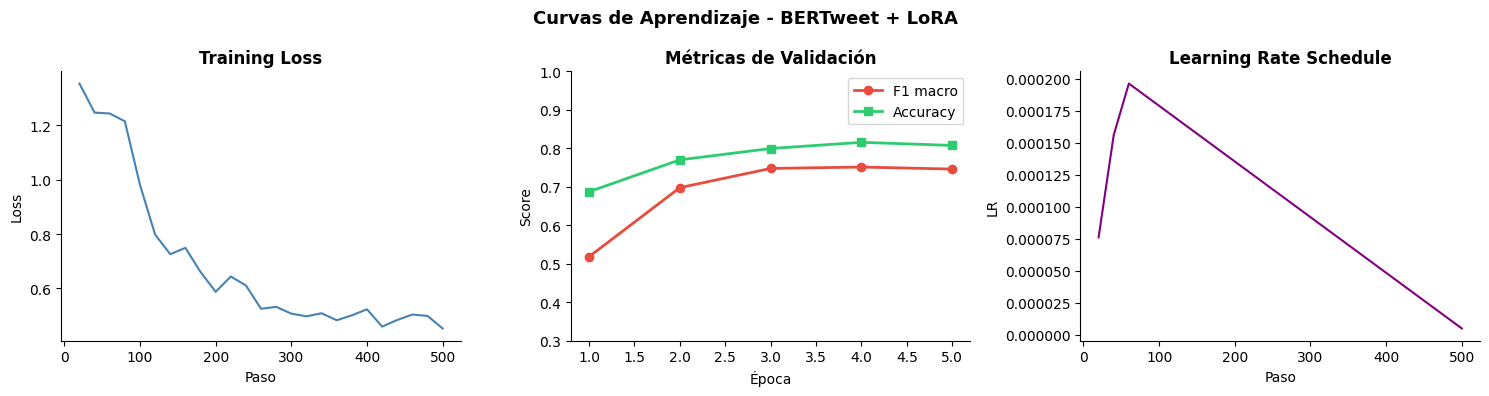

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



  Test — BERTweet + LoRA (PEFT)
              precision    recall  f1-score   support

       anger     0.8564    0.8871    0.8715       558
         joy     0.8462    0.8603    0.8532       358
    optimism     0.7816    0.5528    0.6476       123
     sadness     0.8036    0.8246    0.8140       382

    accuracy                         0.8346      1421
   macro avg     0.8219    0.7812    0.7966      1421
weighted avg     0.8331    0.8346    0.8320      1421



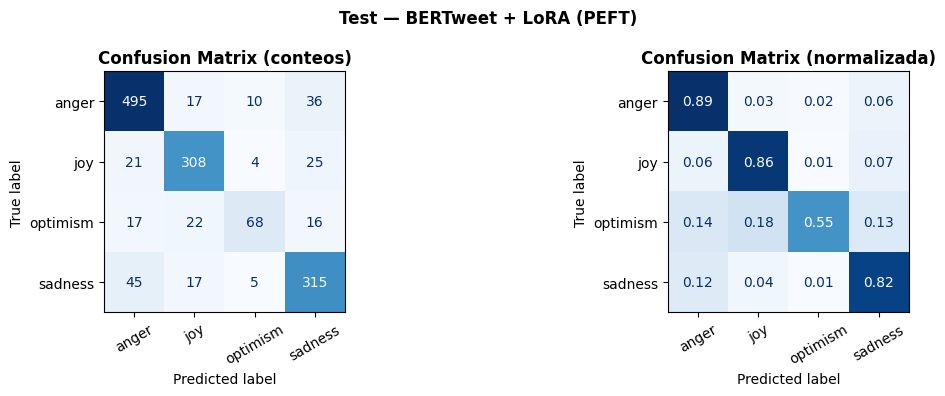

In [8]:
# TODO 5.2 ── Entrenar BERTweet-LoRA
# ─────────────────────────────────────────────────────────────────────────────

# Control de seguridad por si no tomó la celda de configuración superior
if 'LR_LORA' not in locals():
    LR_LORA = 2e-4

# 1. Configuración del Trainer acoplado a los datos del notebook
trainer_lora = make_trainer(
    model=model_bertweet_lora,
    tokenizer=tok_bertweet,
    tokenized_ds=ds_bertweet,
    output_dir="./checkpoints/bertweet-lora",
    lr=LR_LORA
)

# 2. Ejecutamos el entrenamiento eficiente
print(f"Iniciando el entrenamiento optimizado con LoRA (LR={LR_LORA})...")
trainer_lora.train()

# 3. Graficamos las curvas resultantes
plot_training_curves(trainer_lora, title="Curvas de Aprendizaje - BERTweet + LoRA")

# 4. Evaluación en el split de prueba
metrics_bertweet_lora = full_evaluation(
    trainer=trainer_lora,
    test_dataset=ds_bertweet["test"],
    model_name="BERTweet + LoRA (PEFT)"
)

## Push to Hub

Para subir el modelo LoRA al Hub necesitamos fusionarlo primero (`merge_and_unload`), que aplica $W' = W + BA$ y devuelve un modelo estándar sin overhead PEFT.

In [9]:
merged = model_bertweet_lora.merge_and_unload()
merged.push_to_hub(HF_REPO, commit_message="BERTweet LoRA r=8 — merged")
tok_bertweet.push_to_hub(HF_REPO)
print(f"Modelo publicado en: https://huggingface.co/{HF_REPO}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Modelo publicado en: https://huggingface.co/oscarv1114/tweeteval-emotion-bertweet-lora
